In [ ]:
## Data loading

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

DATA_FOLDER = "useddata"
allFileNames = os.listdir(DATA_FOLDER)
csvFileNames = [name for name in allFileNames]
for name in csvFileNames:
    print(f"{name}")

data = {} #ticker -> price table
for filename in csvFileNames:
    filepath = os.path.join(DATA_FOLDER, filename) #full path line
    ticker = filename.replace(".csv","").replace("&","") #tidying up file names
    df = pd.read_csv(filepath, parse_dates=["Date"])
    df = df.sort_values("Date").reset_index(drop=True)
    df = df[["Date", "Open", "High", "Low", "Close"]]
    data[ticker] = df

    print(f"{ticker}: {len(df)} rows, from {df['Date'].min().date()} to {df['Date'].max().date()}")

print(f"Loaded {len(data)} tickers: {list(data.keys())}")



&6E.csv
&CL.csv
&ZN.csv
&GC.csv
&SI.csv
&ES.csv
&NQ.csv
&6J.csv
6E: 4018 rows, from 1999-01-04 to 2014-12-31
CL: 7969 rows, from 1983-03-30 to 2014-12-31
ZN: 8224 rows, from 1982-05-03 to 2014-12-31
GC: 9238 rows, from 1978-03-30 to 2014-12-31
SI: 9218 rows, from 1978-04-27 to 2014-12-31
ES: 4361 rows, from 1997-09-09 to 2014-12-31
NQ: 3913 rows, from 1999-06-21 to 2014-12-31
6J: 8990 rows, from 1979-05-01 to 2014-12-31
Loaded 8 tickers: ['6E', 'CL', 'ZN', 'GC', 'SI', 'ES', 'NQ', '6J']


### Building the Trading Signal

This is where the higher highs and lower lows idea is implemented and calculated.

**My rules and conditions**

- `entryLookback` = number of past days we check for a breakout
- `exitLookback` = a shorter number of days we use to decide when we want to exit

- Go long when today's close is higher than every high in the last `entryLookback` days (higher high)
- Go short when today's close is lower than every low in the last `entryLookback` days (lower low)
- Exit a long when today's close drops below the lowest low of the last `exitLookback` days
- Exit a short when today's close rises above the highest high of the last `exitLookback` days

**Why is `exitLookback` shorter than `entryLookback`?**

If we used the same window for both, we would only exit a long on a full opposite breakdown, which eats up a large portion of the gains. A shorter exit window lets us react faster once a trend stalls, without exiting on every minor volatility event.

**Things I took into consideration**

- **No look-ahead bias:** breakout levels are calculated using days `i-N` up to `i-1`, not including the present day itself. This makes sure we only calculate the breakout level from past days.

In [ ]:
def highestHighLastNDays(highs, n, todayIndex): #This will find the highest value in the "highs" array over N days before present day.
    start = todayIndex - n
    end = todayIndex

    if start < 0 :
        return np.nan
    window = highs[start:end]
    return max(window)

def lowestLowLastNDays(lows, n, todayIndex): #same as the above but smallest value.
    start = todayIndex - n
    end = todayIndex

    if start < 0 :
        return np.nan
    window = lows[start:end]
    return min(window)

""" Let me explain this part, im changing my data frame to add breakout levels and a trading signal column. 
Itll return a new dataframe with all the values unchanged."""
def donchianSignal( df, entryLookback=55, exitLookback=20):
    df = df.copy()
    highs= df["High"].values
    lows = df["Low"].values
    closes = df["Close"].values
    nRows = len(df)

    entryHigh = np.full(nRows, np.nan)
    entryLow = np.full(nRows, np.nan)
    exitHigh = np.full(nRows, np.nan)
    exitLow = np.full(nRows, np.nan)
    position = np.zeros(nRows)

    for i in range(nRows):
        entryHigh[i] = highestHighLastNDays(highs, entryLookback, i)
        entryLow[i] = lowestLowLastNDays(lows, entryLookback, i)
        exitHigh[i] = highestHighLastNDays(highs, exitLookback, i)
        exitLow[i] = lowestLowLastNDays(lows, exitLookback, i)

        if i == 0: #first days have no previous day to compare
            continue

        prevPosition = position[i - 1]
        closeToday = closes[i]

        # not enough data yet to have a valid breakout level
        if np.isnan(entryHigh[i]):
            position[i] = 0
            continue
        # 0 is flat, 1 is take a position long, -1 is take a position short
        if prevPosition == 0:
            if closeToday > entryHigh[i]:
                position[i] = 1 
            elif closeToday < entryLow[i]:
                position[i] = -1 
            else:
                position[i] = 0
        elif prevPosition == 1:
            #stay long unless the exit rule triggers
            if closeToday < exitLow[i]:
                position[i] = 0     
            else:
                position[i] = 1     # stay long
        elif prevPosition == -1:
            # stay short unless the exit rule triggers
            if closeToday > exitHigh[i]:
                position[i] = 0     
            else:
                position[i] = -1    
                
    df["entryHigh"] = entryHigh
    df["entryLow"] = entryLow
    df["exitHigh"] = exitHigh
    df["exitLow"] = exitLow
    df["position"] = position

    return df

    

        

        
    

    

## Position Sizing: Average True Range

One problem I noticed was that Gold might move $$10 /day while EUR/USD moves $0.0005 /day. If we traded 1 contract of each, Gold would dominate our results just because it has bigger absolute price movements.

We can fix this problem by using the Average True Range (ATR) of the instruments. ATR measures how much an instrument typically moves in a day. We size each position so a normal day's move is worth roughly the same amount of risk, regardless of instrument. This is standard practice in the Turtle Trading system and in the CTA/momentum literature (Baltas and Kosowski, 2013).

**True Range** on a given day is the largest of three possible price movements:

1. today's high minus today's low (today's own range)
2. today's high minus yesterday's close (an up-gap)
3. yesterday's close minus today's low (a down-gap)

We take the largest of the three because any one of them could be the "real" range if the market gapped overnight.

**No look-ahead bias:** ATR on day `i` must only use data up to and including day `i`. When we decide the present day's position size, we use day `i-1`'s ATR.


## Strategy Returns
`addReturns`
Computes the strategy's daily return using volatility-based sizing.

For each day `i`:

- `rawReturn[i]` = (close[i] − close[i-1]) / close[i-1]
- `positionUsed` = position decided at **yesterday's** close (`position[i-1]`)
- `ATRUsed` = ATR known as of **yesterday** (`ATR[i-1]`)
- `ATRPct` = `ATRUsed` / close[i-1] (ATR expressed as a % of price)
- `size` = (`riskPerTrade` × `targetDailyVol`) / `ATRPct`
- `strategyReturn[i]` = `positionUsed` × `rawReturn[i]` × `size`

Using **yesterday's** position and ATR together with **today's** actual price change is what keeps this free of look-ahead bias: everything used to make the sizing decision was known before today's price move happened.

In [ ]:
def trueRangeSingleDay(highToday, lowToday, closeYesterday):
    move1 = highToday - lowToday
    move2 = abs(highToday - closeYesterday)
    move3 = abs(closeYesterday - lowToday)
    return max(move1,move3,move2)

def addATR(df, ATRWindow=20): #addition of a ATR column to DF 
    df = df.copy()

    highs = df["High"].values
    lows = df["Low"].values
    closes = df["Close"].values
    nRows = len(df)

    trueRange = np.full(nRows, np.nan)

    for i in range(1, nRows):
        trueRange[i] = trueRangeSingleDay(highs[i], lows[i], closes[i-1])
        
    ATR = np.full(nRows, np.nan)
    for i in range(nRows):
        start = i - ATRWindow + 1 #window includes todays true range
        end = i + 1
        if start < 1:
            continue
        windowValues = trueRange[start:end]
        ATR[i] = sum(windowValues)/len(windowValues)

    df["ATR"] = ATR
    return df



def addReturns(df, riskPerTrade = 1.0, targetDailyVol= 0.01):

    df = df.copy()

    closes= df["Close"].values
    positions = df["position"].values
    ATR = df["ATR"].values
    nRows = len(df)

    rawReturn = np.full(nRows, np.nan)
    strategyReturn = np.full(nRows, np.nan)

    for i in range(1, nRows):
        rawReturn[i] = (closes[i] - closes [i-1]) / closes[i-1]

        positionUsed = positions[i-1]
        ATRUsed = ATR[i-1]

        if np.isnan(ATRUsed) or ATRUsed == 0:
            continue

        ATRPct = ATRUsed / closes[i-1]

        size = (riskPerTrade * targetDailyVol / ATRPct)
        # This line caps the sizing so a low volatility day cannot create excessive leverage
        if size >5:
            size = 5

        strategyReturn[i] = positionUsed * rawReturn[i] * size

    df["rawReturn"] = rawReturn
    df["strategyReturn"] = strategyReturn
    return df


    
    
    

## Comparing Against the Benchmark

Two primary benchmarks we are testing against:

1. **Buy and Hold:** did the trading help, or would I be better off just buying and holding?
2. **12-Month Time Series Momentum** (from Moskowitz, Ooi and Pedersen, 2012): the rule is to look at the return over the past 12 months (252 days). If positive, go long. If negative, go short.


## Building Equity Curves

Turns daily returns into a cumulative growth of $1 curve for each of:

- the Donchian breakout strategy
-  simple 12-month momentum benchmark
- buy and hold

The benchmark return uses the same `rawReturn` column computed for the main strategy, so both are compared on identical price moves.

In [ ]:

def benchmark12Momentum(df, lookbackDays = 252):
    df = df.copy()
    closes = df["Close"].values
    nRows = len(df)

    benchmarkPosition = np.full(nRows, np.nan)

    for i in range(lookbackDays, nRows):
        pastReturn = (closes[i-1] - closes[i-1-lookbackDays]) / closes[i-1-lookbackDays]
        benchmarkPosition[i] = 1 if pastReturn > 0 else -1

    df["benchmarkPosition"] = benchmarkPosition



    benchmarkReturn = np.full(nRows, np.nan)
    for i in range (1, nRows):
        pos = df["benchmarkPosition"].values[i-1] if i-1 >= lookbackDays else np.nan
        if np.isnan(pos):
            continue
        benchmarkReturn[i] = pos * df["rawReturn"].values[i]

    df["benchmarkReturn"] = benchmarkReturn
    return df


"""  Turns daily returns into a cumulative growth of $1 for
    - Donchian breakout strat
    - Simple 12 month momentum benchmark
    - Buy and hold
"""
def buildEquityCurves(df):
    df = df.copy()
    nRows = len(df)

    strategyCurve = np.full(nRows, np.nan)
    benchmarkCurve = np.full(nRows, np.nan)
    buyholdCurve = np.full(nRows, np.nan)

    strategyValue = 1.0
    benchmarkValue = 1.0
    buyholdValue = 1.0

    strategyReturns = df["strategyReturn"].values
    benchmarkReturn = df["benchmarkReturn"].values
    rawReturn = df["rawReturn"].values

    for i in range(nRows):
        if not np.isnan(rawReturn[i]):
            buyholdValue = buyholdValue * (1 +rawReturn[i])
        buyholdCurve[i] = buyholdValue

        if not np.isnan(strategyReturns[i]):
            strategyValue = strategyValue * (1+ strategyReturns[i])
            strategyCurve[i] = strategyValue
        elif strategyValue != 1.0 or i > 0:
            strategyCurve[i] = strategyCurve[i-1] if i > 0 else np.nan

        if not np.isnan(benchmarkReturn[i]):
            benchmarkValue = benchmarkValue * ( 1 + benchmarkReturn[i])
            benchmarkCurve[i] = benchmarkValue
        elif i > 0:
            benchmarkCurve[i] = benchmarkCurve[i-1]

    df["strategyEquity"] = strategyCurve
    df["benchmarkEquity"] = benchmarkCurve
    df["buyholdEquity"] = buyholdCurve
    return df
    


## Sharpe Ratio and the In-Sample / Out-of-Sample Split

Sharpe ratio measures return per unit of risk taken. It's the mean daily return divided by the standard deviation of daily returns, annualized by multiplying by the square root of 252 (the number of trading days in a year). A higher Sharpe means more return for the same amount of volatility.

`CUTOFF` splits the data at 2010-01-01. Everything before this date is in-sample. This is the period the strategy's parameters (entryLookback, exitLookback, ATR window) were decided from, using values taken directly from the Turtle Trading system, not tuned on this data. Everything from 2010-01-01 to the end of the data (2014-12-31) is out-of-sample for 5 years.

This split does not change anything about how the strategy or its signals were calculated. `donchianSignal`, `addATR`, and `addReturns` already ran on the full history, so the rolling windows have real prior data at every point, including the first days of 2010. The split only changes which rows we look at when reporting results. In-sample rows tell us how the strategy performed historically, out-of-sample rows tell us how it performed on data it never had any influence from.

In [ ]:
CUTOFF = pd.Timestamp("2010-01-01")

def sharpeRatio(returns):
    r = returns.dropna()
    if r.std() == 0 or len(r) == 0:
        return np.nan
    return (r.mean() / r.std()) * np.sqrt(252)

# split each by date and print its Sharpe
basketResults = {}
for ticker in data.keys():
    df = donchianSignal(data[ticker])
    df = addATR(df)
    df = addReturns(df)
    df = benchmark12Momentum(df)
    df = buildEquityCurves(df)
    basketResults[ticker] = df

    inSample = df[df["Date"] < CUTOFF]
    outOfSample = df[df["Date"] >= CUTOFF]
    print(f"{ticker}: In-sample Sharpe = {sharpeRatio(inSample['strategyReturn']):.3f}, "
          f"Out-of-sample Sharpe = {sharpeRatio(outOfSample['strategyReturn']):.3f}")

6E: In-sample Sharpe = 0.304, Out-of-sample Sharpe = 0.553
CL: In-sample Sharpe = 0.071, Out-of-sample Sharpe = 0.113
ZN: In-sample Sharpe = 0.282, Out-of-sample Sharpe = -0.824
GC: In-sample Sharpe = 0.062, Out-of-sample Sharpe = 0.199
SI: In-sample Sharpe = 0.017, Out-of-sample Sharpe = 0.284
ES: In-sample Sharpe = -0.118, Out-of-sample Sharpe = -0.153
NQ: In-sample Sharpe = 0.248, Out-of-sample Sharpe = 0.196
6J: In-sample Sharpe = 0.486, Out-of-sample Sharpe = 0.527



6E: in-sample Sharpe = 0.304, out-of-sample Sharpe = 0.553


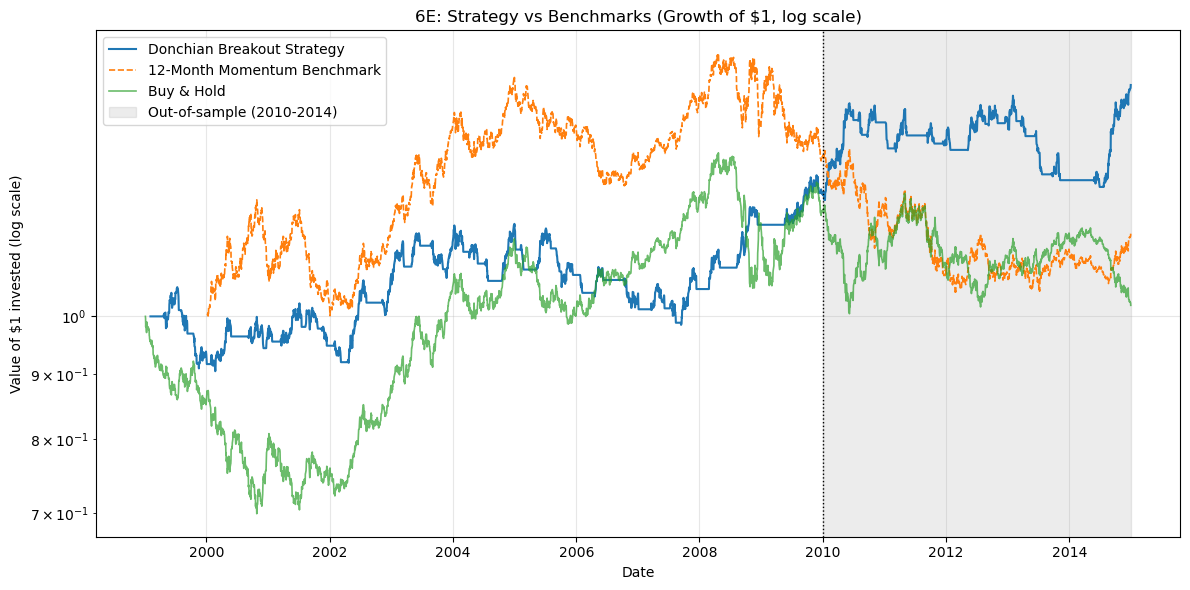


CL: in-sample Sharpe = 0.071, out-of-sample Sharpe = 0.113


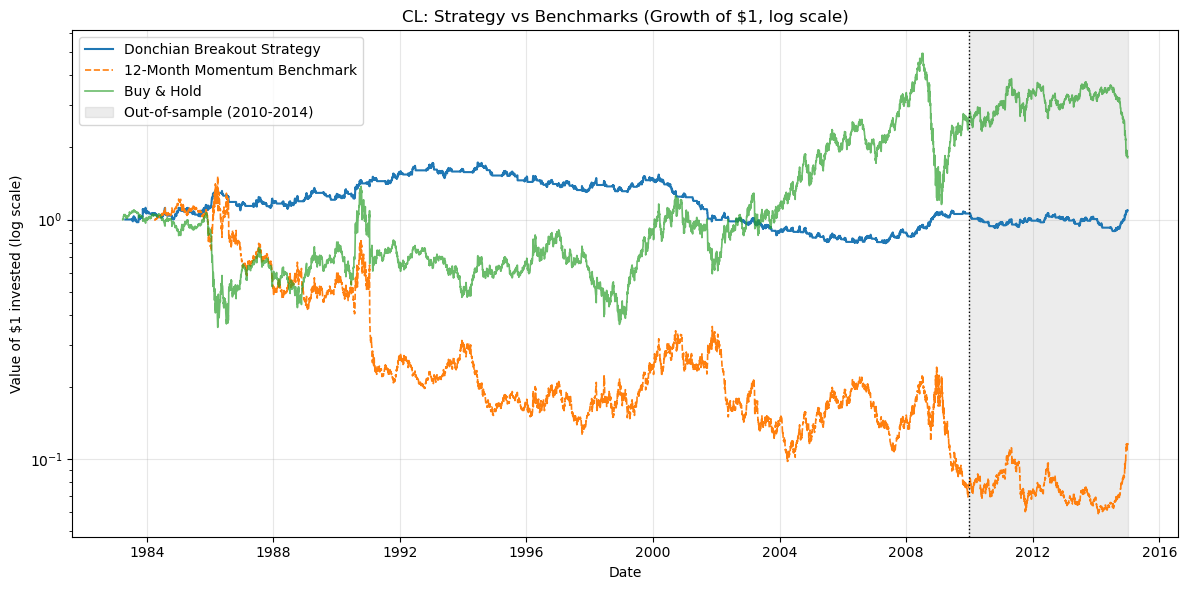


ZN: in-sample Sharpe = 0.282, out-of-sample Sharpe = -0.824


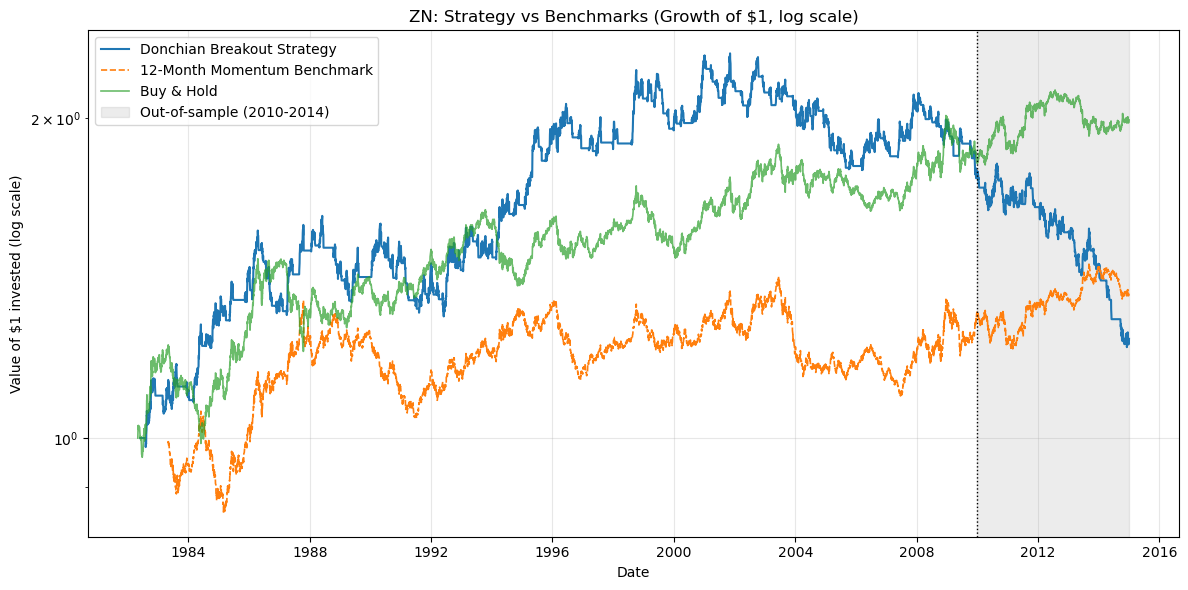


GC: in-sample Sharpe = 0.062, out-of-sample Sharpe = 0.199


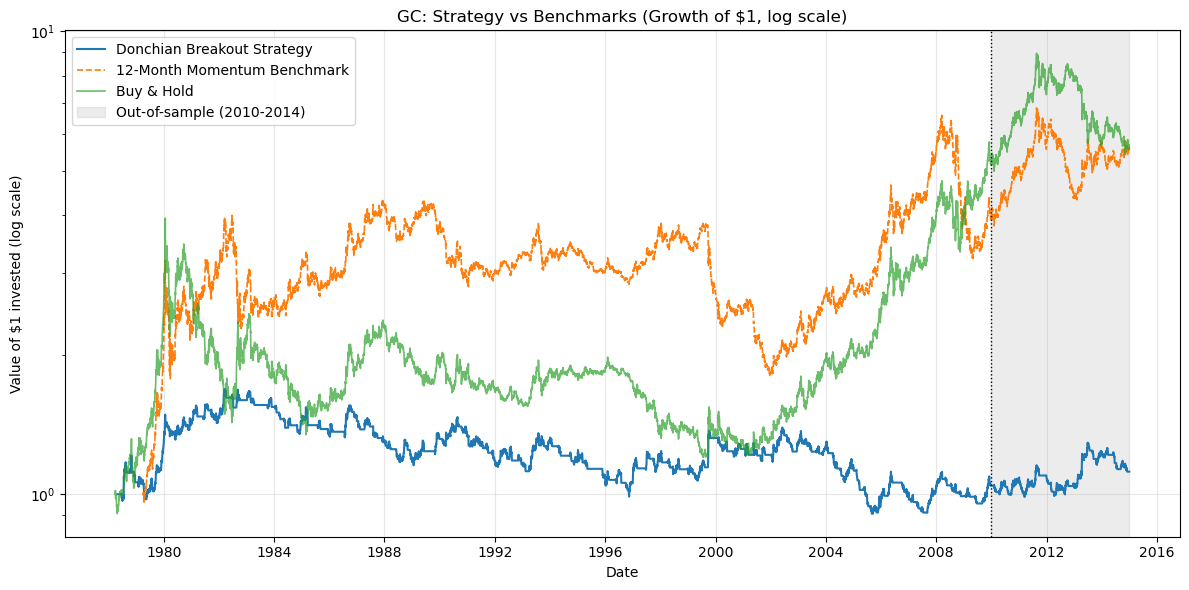


SI: in-sample Sharpe = 0.017, out-of-sample Sharpe = 0.284


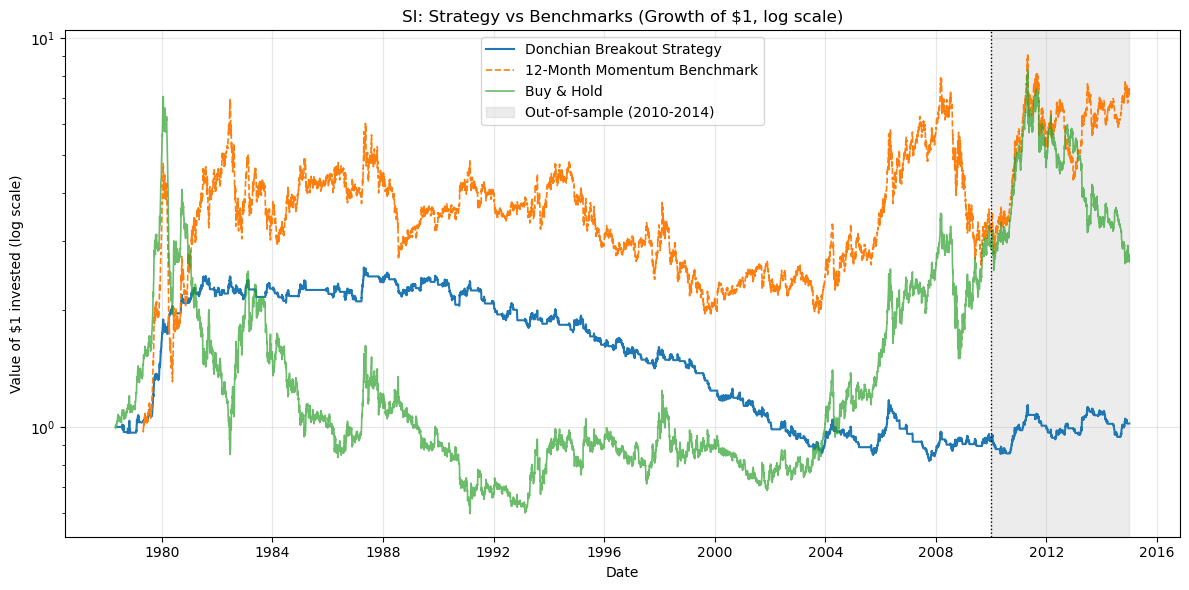


ES: in-sample Sharpe = -0.118, out-of-sample Sharpe = -0.153


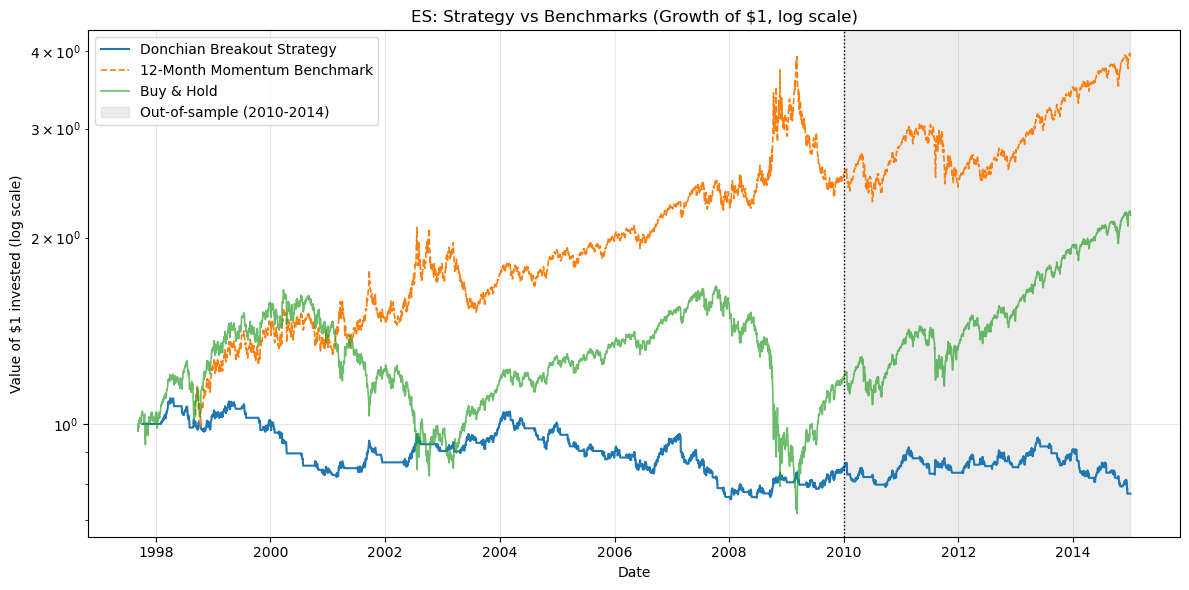


NQ: in-sample Sharpe = 0.248, out-of-sample Sharpe = 0.196


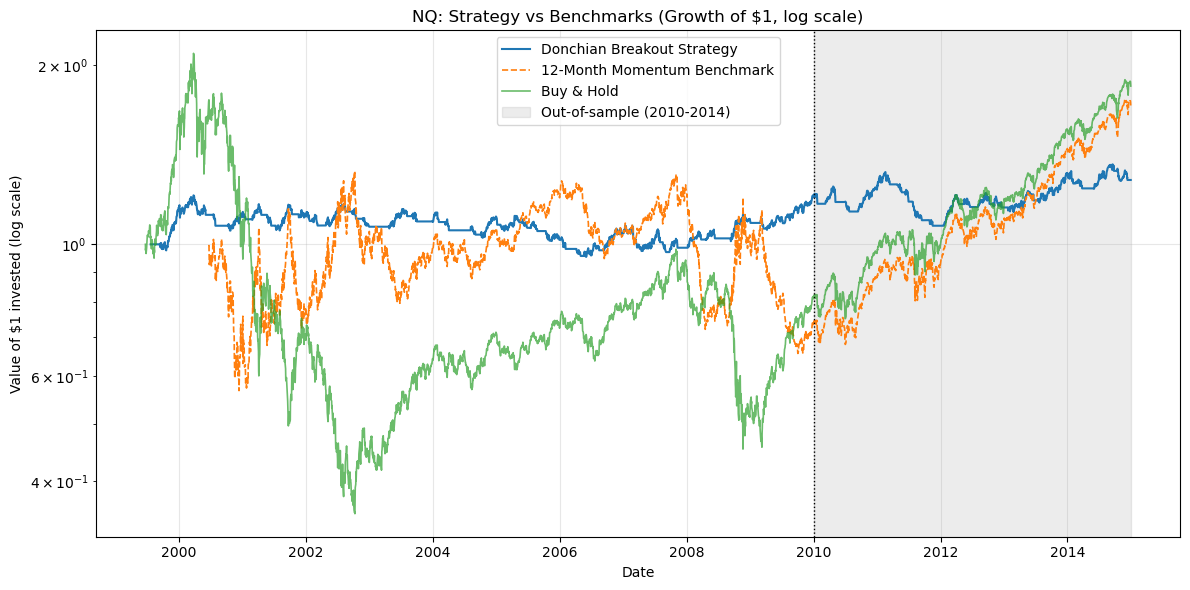


6J: in-sample Sharpe = 0.486, out-of-sample Sharpe = 0.527


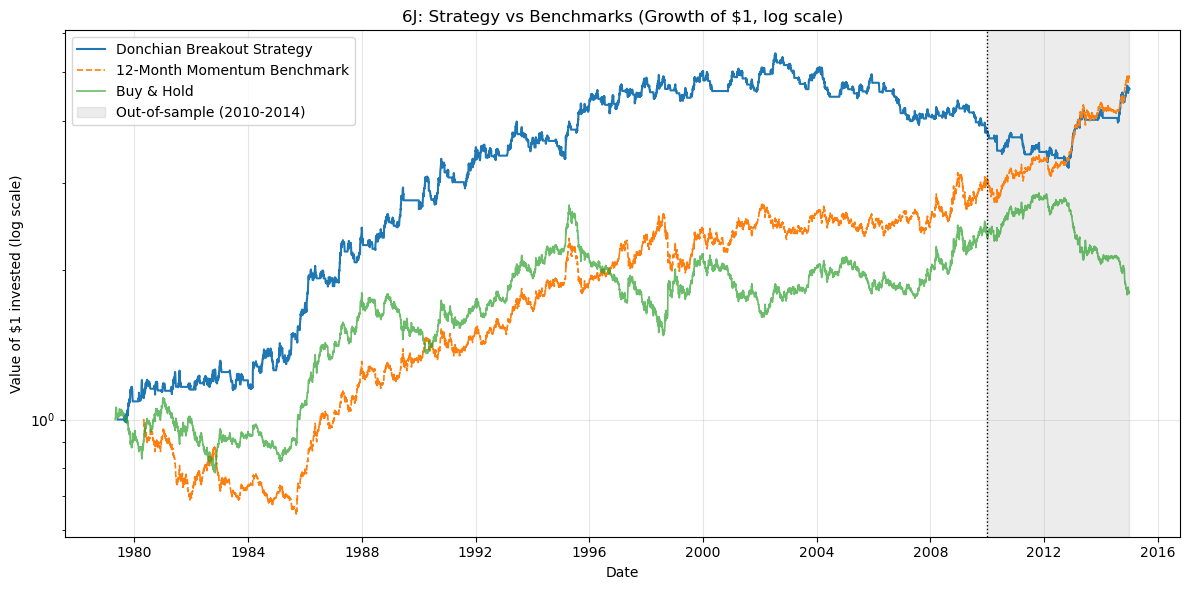

In [ ]:
#everything below is what gets added

def plot_equity_curves(df, ticker_name, cutoff=CUTOFF):
    """
    Plots the three equity curves on one chart, with the in-sample /
    out-of-sample boundary marked visually
    """
    fig, ax = plt.subplots(figsize=(12, 6))

    ax.plot(df["Date"], df["strategyEquity"], label="Donchian Breakout Strategy", linewidth=1.5)
    ax.plot(df["Date"], df["benchmarkEquity"], label="12-Month Momentum Benchmark", linewidth=1.2, linestyle="--")
    ax.plot(df["Date"], df["buyholdEquity"], label="Buy & Hold", linewidth=1.2, alpha=0.7)

    ax.axvspan(cutoff, df["Date"].max(), color="grey", alpha=0.15, label="Out-of-sample (2010-2014)")
    ax.axvline(cutoff, color="black", linewidth=1, linestyle=":")

    ax.set_yscale("log")
    ax.set_title(f"{ticker_name}: Strategy vs Benchmarks (Growth of $1, log scale)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Value of $1 invested (log scale)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


for ticker in data.keys():
    df = donchianSignal(data[ticker])
    df = addATR(df)
    df = addReturns(df)
    df = benchmark12Momentum(df)
    df = buildEquityCurves(df)

    tickerInSample = df[df["Date"] < CUTOFF]
    tickerOutOfSample = df[df["Date"] >= CUTOFF]
    print(f"\n{ticker}: in-sample Sharpe = {sharpeRatio(tickerInSample['strategyReturn']):.3f}, "
          f"out-of-sample Sharpe = {sharpeRatio(tickerOutOfSample['strategyReturn']):.3f}")

    plot_equity_curves(df, ticker)

## Combining Instruments Into One Portfolio

Combines multiple instruments' `strategyReturn` into one portfolio.

Each instrument has its own `Date` column, and they don't all cover the same dates (GC starts 1978, ES starts 1997). `pd.concat` lines every instrument up by matching actual calendar dates, not by row position, and fills NaN wherever an instrument has no data yet.

**How the averaging works:** for every date, average the `strategyReturn` across every instrument that has a valid value that day. Instruments with shorter history simply aren't counted before they have data.

The averaged daily returns are then compounded into `portfolioEquity`, a growth of $1 curve for the combined portfolio

           Date  portfolioReturn  portfolioEquity
9279 2014-12-24         0.000004         2.398230
9280 2014-12-26         0.000640         2.399765
9281 2014-12-29         0.001632         2.403681
9282 2014-12-30        -0.000881         2.401563
9283 2014-12-31         0.001738         2.405738
Final portfolio equity (growth of $1): 2.4057375515743007


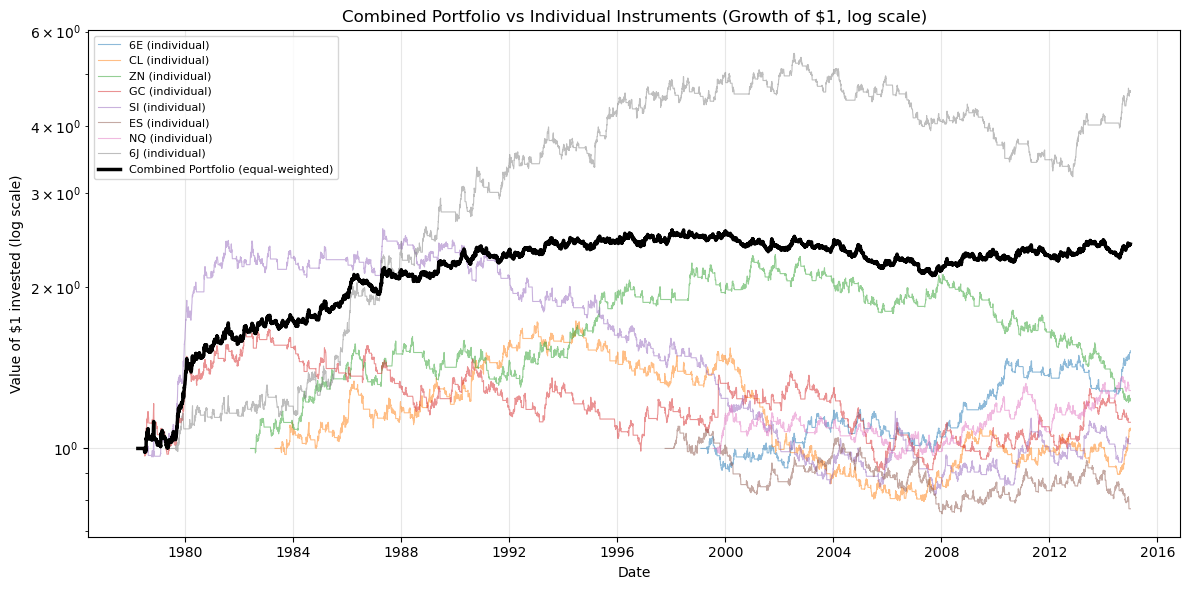

In [27]:
def combinePortfolio(basketResults):

    frames = []
    for ticker, df in basketResults.items():
        singleAssetReturns = df[["Date", "strategyReturn"]].copy()
        singleAssetReturns = singleAssetReturns.rename(columns={"strategyReturn": ticker})
        singleAssetReturns = singleAssetReturns.set_index("Date")
        frames.append(singleAssetReturns)

    wideTable = pd.concat(frames, axis=1, sort=True)

    portfolioReturn = wideTable.mean(axis=1, skipna=True)
    portfolioEquity = (1 + portfolioReturn.fillna(0)).cumprod()

    result = pd.DataFrame({
        "Date": portfolioEquity.index,
        "portfolioReturn": portfolioReturn.values,
        "portfolioEquity": portfolioEquity.values,
    }).reset_index(drop=True)

    return result


def plotPortfolioVsIndividual(portfolioDf, basketResults):
    """
    Shows the combined portfolio equity curve against each individual
    instrument's own strategy equity curve, so you can see the
    diversification effect directly.
    """
    fig, ax = plt.subplots(figsize=(12, 6))

    for ticker, df in basketResults.items():
        ax.plot(df["Date"], df["strategyEquity"], linewidth=0.8, alpha=0.5, label=f"{ticker} (individual)")

    ax.plot(portfolioDf["Date"], portfolioDf["portfolioEquity"],
            linewidth=2.5, color="black", label="Combined Portfolio (equal-weighted)")

    ax.set_yscale("log")
    ax.set_title("Combined Portfolio vs Individual Instruments (Growth of $1, log scale)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Value of $1 invested (log scale)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## Run the pipeline on every ticker in data folder, no manual basket list
basketResults = {}
for ticker in data.keys():
    df = donchianSignal(data[ticker])
    df = addATR(df)
    df = addReturns(df)
    df = benchmark12Momentum(df)
    df = buildEquityCurves(df)
    basketResults[ticker] = df

portfolioDf = combinePortfolio(basketResults)

##  look at what combinePortfolio produced
print(portfolioDf.tail())
print("Final portfolio equity (growth of $1):", portfolioDf["portfolioEquity"].iloc[-1])

plotPortfolioVsIndividual(portfolioDf, basketResults)

## Performance Statistics

Four statistics are calculated for every instrument.

**Sharpe ratio.** Mean daily return divided by the standard deviation of daily returns, annualized. Measures return per unit of total risk taken.

**Sortino ratio.** Same idea as Sharpe, but only penalizes downside volatility. The standard deviation is computed using only the negative returns, not all of them. The reasoning here is that an investor is only bothered by downside volatility. Sortino reflects that. Sharpe treats both the same, which punishes a strategy for having good days.

**Max drawdown.** The largest peak-to-trough decline in the equity curve, as a percentage. Calculated by tracking the running maximum the equity curve has reached so far (the highest point it's ever been), then measuring how far below that peak the curve falls at its worst point. This tells us the worst loss an investor holding this strategy would have actually sat through.

**Win rate.** Percentage of days with a nonzero position that were profitable. Flat days, where strategyReturn is 0 because no position was held, are excluded, since a day the strategy wasn't even trading isn't a win or a loss.

**Annualized return.** Compounds the daily returns into a total return over the whole period, then converts that into a per-year figure using the number of years covered. This makes returns comparable across periods of different length, since the in-sample period is decades long and the out-of-sample period is only 5 years.

In [28]:
#Statistics Cell 
def sortinoRatio(returns):
    """
    Like Sharpe, but only penalizes DOWNSIDE volatility
    """
    r = returns.dropna()
    downside = r[r < 0]
    if len(downside) == 0 or downside.std() == 0:
        return np.nan
    return (r.mean() / downside.std()) * np.sqrt(252)


def maxDrawdown(equityCurve):
    """
    The largest peak-to-trough decline as a
    percentage. 
    """
    equity = equityCurve.dropna()
    if len(equity) == 0:
        return np.nan
    runningMax = equity.cummax()
    drawdown = (equity - runningMax) / runningMax
    return drawdown.min()


def winRate(returns):
    """
    Percentage of days with a nonzero position that were profitable.
    Flat days (strategyReturn == 0, no position held) are excluded.
    """
    r = returns.dropna()
    active = r[r != 0]
    if len(active) == 0:
        return np.nan
    return (active > 0).mean()


def annualizedReturn(returns):
    r = returns.dropna()
    if len(r) == 0:
        return np.nan
    totalReturn = (1 + r).prod() - 1
    years = len(r) / 252
    if years == 0:
        return np.nan
    return (1 + totalReturn) ** (1 / years) - 1


def summarizeStats(returns, equityCurve, label):
    """Builds one row of summary statistics for a return series."""
    return {
        "label": label,
        "annualizedReturn": annualizedReturn(returns),
        "sharpe": sharpeRatio(returns),
        "sortino": sortinoRatio(returns),
        "maxDrawdown": maxDrawdown(equityCurve),
        "winRate": winRate(returns),
    }


## Build a full results table
statsRows = []

for ticker, df in basketResults.items():
    isSlice = df[df["Date"] < CUTOFF]
    oosSlice = df[df["Date"] >= CUTOFF]
    statsRows.append(summarizeStats(isSlice["strategyReturn"], isSlice["strategyEquity"], f"{ticker} (in-sample)"))
    statsRows.append(summarizeStats(oosSlice["strategyReturn"], oosSlice["strategyEquity"], f"{ticker} (out-of-sample)"))

portfolioIS = portfolioDf[portfolioDf["Date"] < CUTOFF]
portfolioOOS = portfolioDf[portfolioDf["Date"] >= CUTOFF]
statsRows.append(summarizeStats(portfolioIS["portfolioReturn"], portfolioIS["portfolioEquity"], "Combined Portfolio (in-sample)"))
statsRows.append(summarizeStats(portfolioOOS["portfolioReturn"], portfolioOOS["portfolioEquity"], "Combined Portfolio (out-of-sample)"))

statsTable = pd.DataFrame(statsRows)
statsTable["annualizedReturn"] = statsTable["annualizedReturn"].apply(lambda x: f"{x:.2%}")
statsTable["maxDrawdown"] = statsTable["maxDrawdown"].apply(lambda x: f"{x:.2%}")
statsTable["winRate"] = statsTable["winRate"].apply(lambda x: f"{x:.1%}")
statsTable["sharpe"] = statsTable["sharpe"].round(3)
statsTable["sortino"] = statsTable["sortino"].round(3)

statsTable

,label,annualizedReturn,sharpe,sortino,maxDrawdown,winRate
0,6E (in-sample),2.10%,0.304,0.349,-16.74%,52.1%
1,6E (out-of-sample),3.96%,0.553,0.652,-15.26%,52.2%
2,CL (in-sample),0.22%,0.071,0.079,-53.99%,51.8%
3,CL (out-of-sample),0.59%,0.113,0.136,-15.96%,50.2%
4,ZN (in-sample),2.12%,0.282,0.331,-23.69%,51.1%
5,ZN (out-of-sample),-7.00%,-0.824,-1.065,-32.81%,47.6%
6,GC (in-sample),0.13%,0.062,0.068,-46.21%,50.0%
7,GC (out-of-sample),1.41%,0.199,0.237,-14.21%,52.4%
8,SI (in-sample),-0.27%,0.017,0.019,-68.17%,50.0%
9,SI (out-of-sample),2.16%,0.284,0.319,-18.46%,49.6%
